In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
data = {
    "Student_ID": [
        "S001","S002","S003","S004","S005",
        "S006","S007","S008","S009","S010",
        "S011","S012","S013","S014","S015",
        "S016","S017","S018","S019","S020"
    ],

    "Age": [
        5,6,5,7,6,
        5,7,6,5,7,
        6,5,7,6,5,
        6,7,5,6,7
    ],

    "Gender": [
        "F","M","F","M","F",
        "M","F","M","F","M",
        "F","M","F","M","F",
        "M","F","M","F","M"
    ],

    "Attendance": [
        95,88,98,82,94,
        75,97,90,85,96,
        91,70,99,87,93,
        89,96,84,92,88
    ],

    "Math_Score": [
        85,72,90,65,88,
        55,92,78,70,86,
        80,50,95,68,84,
        76,91,62,83,79
    ],

    "Reading_Score": [
        80,75,92,68,85,
        60,90,82,73,88,
        78,54,94,72,86,
        81,89,64,85,77
    ],

    "Practical_Life": [
        90,80,95,70,91,
        62,94,76,75,85,
        84,58,96,69,88,
        79,93,67,87,82
    ],

    "Social_Skill": [
        88,78,94,72,89,
        58,95,80,71,87,
        82,52,97,70,85,
        80,92,65,86,79
    ],

    "Concentration": [
        92,70,96,66,90,
        52,93,79,69,89,
        81,48,95,65,87,
        77,94,60,88,76
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.head()

Dataset created successfully!
Number of rows: 20
Number of columns: 9


,Student_ID,Age,Gender,Attendance,Math_Score,Reading_Score,Practical_Life,Social_Skill,Concentration
0,S001,5,F,95,85,80,90,88,92
1,S002,6,M,88,72,75,80,78,70
2,S003,5,F,98,90,92,95,94,96
3,S004,7,M,82,65,68,70,72,66
4,S005,6,F,94,88,85,91,89,90


In [7]:
score_columns = [
    "Math_Score",
    "Reading_Score",
    "Practical_Life",
    "Social_Skill",
    "Concentration"
]

df["Overall_Score"] = df[score_columns].mean(axis=1)

df["Performance"] = pd.cut(
    df["Overall_Score"],
    bins=[0, 59, 74, 89, 100],
    labels=["Poor", "Average", "Good", "Excellent"]
)

print(df[["Student_ID", "Overall_Score", "Performance"]].head(10))

  Student_ID  Overall_Score Performance
0       S001           87.0        Good
1       S002           75.0        Good
2       S003           93.4   Excellent
3       S004           68.2     Average
4       S005           88.6        Good
5       S006           57.4        Poor
6       S007           92.8   Excellent
7       S008           79.0        Good
8       S009           71.6     Average
9       S010           87.0        Good


In [8]:
df.to_csv("montessori_management.csv", index=False)

print("Dataset saved as montessori_management.csv")

Dataset saved as montessori_management.csv


In [9]:
df = pd.read_csv("montessori_management.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (20, 11)


,Student_ID,Age,Gender,Attendance,Math_Score,Reading_Score,Practical_Life,Social_Skill,Concentration,Overall_Score,Performance
0,S001,5,F,95,85,80,90,88,92,87.0,Good
1,S002,6,M,88,72,75,80,78,70,75.0,Good
2,S003,5,F,98,90,92,95,94,96,93.4,Excellent
3,S004,7,M,82,65,68,70,72,66,68.2,Average
4,S005,6,F,94,88,85,91,89,90,88.6,Good


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      20 non-null     object 
 1   Age             20 non-null     int64  
 2   Gender          20 non-null     object 
 3   Attendance      20 non-null     int64  
 4   Math_Score      20 non-null     int64  
 5   Reading_Score   20 non-null     int64  
 6   Practical_Life  20 non-null     int64  
 7   Social_Skill    20 non-null     int64  
 8   Concentration   20 non-null     int64  
 9   Overall_Score   20 non-null     float64
 10  Performance     20 non-null     object 
dtypes: float64(1), int64(7), object(3)
memory usage: 1.8+ KB


In [11]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Attendance', 'Math_Score',
       'Reading_Score', 'Practical_Life', 'Social_Skill', 'Concentration',
       'Overall_Score', 'Performance'],
      dtype='object')

In [12]:
df.describe()

,Age,Attendance,Math_Score,Reading_Score,Practical_Life,Social_Skill,Concentration,Overall_Score
count,20.000000,20.00000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,5.950000,89.45000,77.450000,78.650000,81.05000,80.000000,78.350000,79.100000
std,0.825578,7.54966,12.592709,10.922093,11.33915,12.260334,14.701504,12.253549
min,5.000000,70.00000,50.000000,54.000000,58.00000,52.000000,48.000000,52.400000
25%,5.000000,86.50000,69.500000,72.750000,73.75000,71.750000,68.250000,70.900000
50%,6.000000,90.50000,79.500000,80.500000,83.00000,81.000000,80.000000,80.000000
75%,7.000000,95.25000,86.500000,86.500000,90.25000,88.250000,90.500000,87.400000
max,7.000000,99.00000,95.000000,94.000000,96.00000,97.000000,96.000000,95.400000


In [13]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Attendance,0
Math_Score,0
Reading_Score,0
Practical_Life,0
Social_Skill,0
Concentration,0
Overall_Score,0


In [14]:
df.duplicated().sum()

np.int64(0)

Duplicate records can affect analysis and model training, so they should be identified and removed.

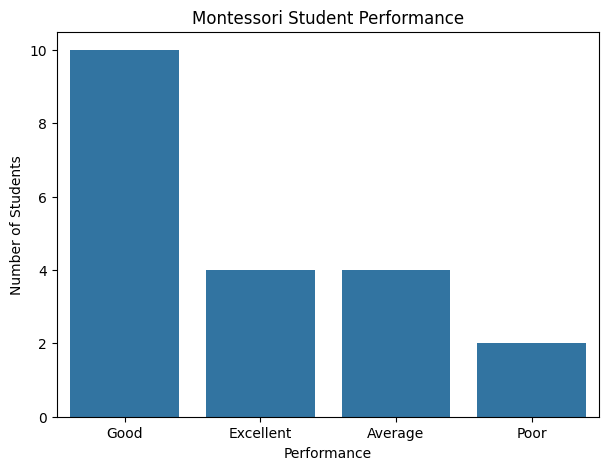

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Performance")

plt.title("Montessori Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

The graph shows how students are distributed among Poor, Average, Good, and Excellent performance categories.

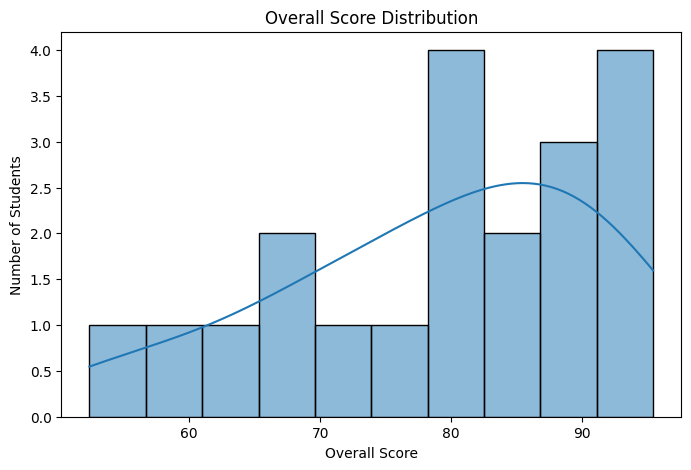

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["Overall_Score"], bins=10, kde=True)

plt.title("Overall Score Distribution")
plt.xlabel("Overall Score")
plt.ylabel("Number of Students")

plt.show()

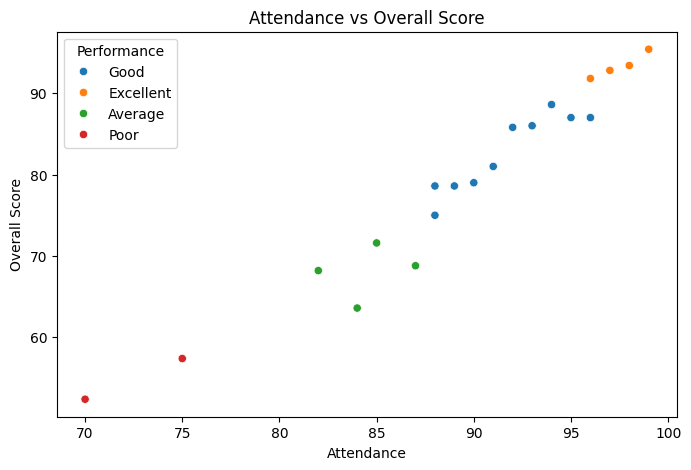

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Overall_Score",
    hue="Performance"
)

plt.title("Attendance vs Overall Score")
plt.xlabel("Attendance")
plt.ylabel("Overall Score")

plt.show()

This graph helps examine the relationship between attendance and overall student performance.

In [18]:
df.loc[2, "Math_Score"] = np.nan
df.loc[5, "Reading_Score"] = -10
df.loc[8, "Age"] = 20
df.loc[10, "Attendance"] = -5

print("Missing values:")
print(df.isnull().sum())

print("\nNegative values:")
print((df.select_dtypes(include=np.number) < 0).sum())

Missing values:
Student_ID        0
Age               0
Gender            0
Attendance        0
Math_Score        1
Reading_Score     0
Practical_Life    0
Social_Skill      0
Concentration     0
Overall_Score     0
Performance       0
dtype: int64

Negative values:
Age               0
Attendance        1
Math_Score        0
Reading_Score     1
Practical_Life    0
Social_Skill      0
Concentration     0
Overall_Score     0
dtype: int64


In [19]:
numeric_columns = [
    "Age",
    "Attendance",
    "Math_Score",
    "Reading_Score",
    "Practical_Life",
    "Social_Skill",
    "Concentration"
]

for column in numeric_columns:
    df.loc[df[column] < 0, column] = np.nan

print("Negative values removed.")

Negative values removed.


Invalid negative values, missing values, unrealistic ages, and duplicate records were handled to improve data quality.

In [20]:
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values filled.")

Missing values filled.


In [21]:
df.loc[(df["Age"] < 3) | (df["Age"] > 10), "Age"] = df["Age"].median()

print("Age outliers fixed.")

Age outliers fixed.


In [22]:
df.loc[(df["Attendance"] > 100), "Attendance"] = 100

print("Attendance values fixed.")

Attendance values fixed.


In [23]:
for column in score_columns:
    df.loc[df[column] > 100, column] = 100

print("Score values fixed.")

Score values fixed.


In [24]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Current shape:", df.shape)

Duplicate rows removed.
Current shape: (20, 11)


In [25]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_ID        0
Age               0
Gender            0
Attendance        0
Math_Score        0
Reading_Score     0
Practical_Life    0
Social_Skill      0
Concentration     0
Overall_Score     0
Performance       0
dtype: int64


In [26]:
df["Development_Score"] = df[
    ["Practical_Life", "Social_Skill", "Concentration"]
].mean(axis=1)

print(
    df[
        [
            "Student_ID",
            "Development_Score"
        ]
    ].head()
)

  Student_ID  Development_Score
0       S001          90.000000
1       S002          76.000000
2       S003          95.000000
3       S004          69.333333
4       S005          90.000000


In [27]:
df["Attendance_Category"] = pd.cut(
    df["Attendance"],
    bins=[0, 74, 89, 100],
    labels=["Low", "Average", "High"]
)

print(df[["Student_ID", "Attendance", "Attendance_Category"]].head())

  Student_ID  Attendance Attendance_Category
0       S001        95.0                High
1       S002        88.0             Average
2       S003        98.0                High
3       S004        82.0             Average
4       S005        94.0                High


In [28]:
features = [
    "Attendance",
    "Math_Score",
    "Reading_Score",
    "Practical_Life",
    "Social_Skill",
    "Concentration",
    "Development_Score"
]

X = df[features]

y = df["Performance"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Attendance', 'Math_Score', 'Reading_Score', 'Practical_Life', 'Social_Skill', 'Concentration', 'Development_Score']

X shape: (20, 7)
y shape: (20,)


The selected features represent attendance, academic performance, and Montessori developmental skills.

In [29]:
print("Vectorization is not required because the selected features are numerical.")

Vectorization is not required because the selected features are numerical.


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 7)
Testing data: (4, 7)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [32]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [33]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [34]:
logistic_prediction = logistic_model.predict(X_test)

print("Predictions:")
print(logistic_prediction)

Predictions:
['Average' 'Good' 'Good' 'Excellent']


In [35]:
print(
    classification_report(
        y_test,
        logistic_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         1
   Excellent       1.00      1.00      1.00         1
        Good       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [36]:
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [37]:
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [38]:
rf_prediction = random_forest_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_prediction)

Random Forest Predictions:
['Average' 'Good' 'Good' 'Excellent']


In [39]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 1.0


In [41]:
print(
    classification_report(
        y_test,
        rf_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         1
   Excellent       1.00      1.00      1.00         1
        Good       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [63]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_prediction = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 1.0


In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Random Forest       1.0


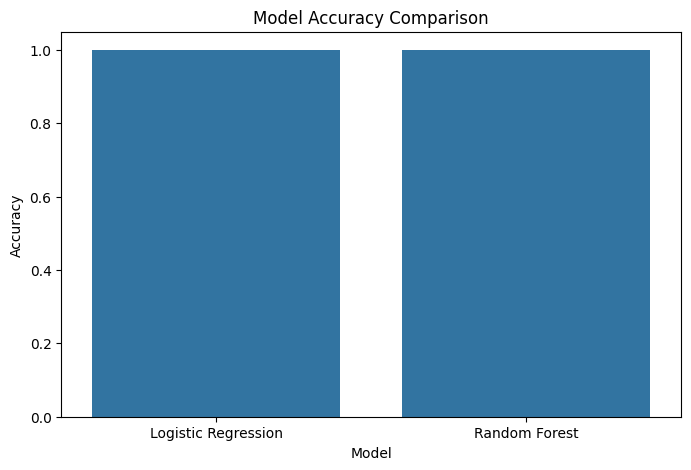

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [66]:
cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

Cross-validation scores:
[1.   1.   1.   0.75 0.75]

Mean CV Accuracy:
0.9


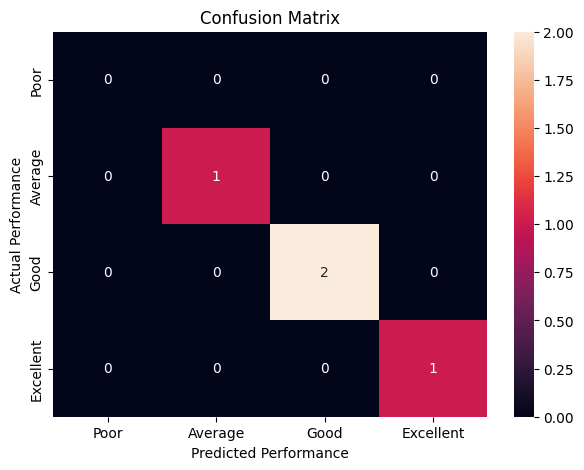

In [67]:
cm = confusion_matrix(
    y_test,
    rf_prediction,
    labels=["Poor", "Average", "Good", "Excellent"]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Poor", "Average", "Good", "Excellent"],
    yticklabels=["Poor", "Average", "Good", "Excellent"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")

plt.show()

The confusion matrix shows which performance categories were predicted correctly and where the model made incorrect predictions.

In [68]:
joblib.dump(
    random_forest_model,
    "montessori_management_model.pkl"
)

print("Model saved successfully!")
print("File: montessori_management_model.pkl")

Model saved successfully!
File: montessori_management_model.pkl


The trained model is saved so it can be reused later without training it again.

In [69]:
loaded_model = joblib.load(
    "montessori_management_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [70]:
def predict_student(
    attendance,
    math_score,
    reading_score,
    practical_life,
    social_skill,
    concentration
):

    development_score = np.mean([
        practical_life,
        social_skill,
        concentration
    ])

    new_student = pd.DataFrame({
        "Attendance": [attendance],
        "Math_Score": [math_score],
        "Reading_Score": [reading_score],
        "Practical_Life": [practical_life],
        "Social_Skill": [social_skill],
        "Concentration": [concentration],
        "Development_Score": [development_score]
    })

    prediction = loaded_model.predict(new_student)

    return prediction[0]

In [71]:
result = predict_student(
    95,
    85,
    88,
    90,
    92,
    91
)

print("Predicted Student Performance:", result)

Predicted Student Performance: Good


The prototype allows new student information to be entered and produces a predicted performance category using the saved machine-learning model.